In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
d:\Dev\Projects\traffic-accident-ml\.venv\Scripts\python.exe

Python version:
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd

DATA_PATH = "../data/raw/dft-road-casualty-statistics-collision-last-5-years.csv"

df = pd.read_csv(
    DATA_PATH,
    nrows=10_000
)

print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 10,000
Jumlah kolom: 44


In [3]:
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804,519612,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0,1
1,202417S111924,2024,17S111924,444670,520502,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1,0
2,2025111687011,2025,111687011,427772,515144,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0,1
3,2025070326701,2025,070326701,351585,382993,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0,0
4,2025070353559,2025,070353559,351101,382954,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0,1


In [4]:
df.columns.tolist()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

In [5]:
print("Shape:", df.shape)
print("\n5 data pertama:")
display(df.head())

Shape: (10000, 44)

5 data pertama:


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804,519612,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0,1
1,202417S111924,2024,17S111924,444670,520502,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1,0
2,2025111687011,2025,111687011,427772,515144,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0,1
3,2025070326701,2025,070326701,351585,382993,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0,0
4,2025070353559,2025,070353559,351101,382954,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0,1


In [6]:
df.dtypes

collision_index                                         str
collision_year                                        int64
collision_ref_no                                        str
location_easting_osgr                                 int64
location_northing_osgr                                int64
longitude                                           float64
latitude                                            float64
police_force                                          int64
collision_severity                                    int64
number_of_vehicles                                    int64
number_of_casualties                                  int64
date                                                    str
day_of_week                                           int64
time                                                    str
local_authority_district                              int64
local_authority_ons_district                            str
local_authority_highway                 

In [7]:
missing = df.isna().sum()

missing = (
    missing[missing > 0]
    .sort_values(ascending=False)
)

missing

Series([], dtype: int64)

In [8]:
important_columns = [
    "collision_severity",
    "number_of_vehicles",
    "number_of_casualties",
    "day_of_week",
    "first_road_class",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "trunk_road_flag"
]

for col in important_columns:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"Jumlah nilai unik: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False).sort_index())


collision_severity
Jumlah nilai unik: 3
collision_severity
1     137
2    2614
3    7249
Name: count, dtype: int64

number_of_vehicles
Jumlah nilai unik: 8
number_of_vehicles
1     3069
2     6067
3      670
4      128
5       37
6       17
7       10
10       2
Name: count, dtype: int64

number_of_casualties
Jumlah nilai unik: 8
number_of_casualties
1    8024
2    1396
3     385
4     134
5      39
6      16
7       5
8       1
Name: count, dtype: int64

day_of_week
Jumlah nilai unik: 7
day_of_week
1    1102
2    1390
3    1493
4    1466
5    1516
6    1635
7    1398
Name: count, dtype: int64

first_road_class
Jumlah nilai unik: 6
first_road_class
1     326
2      21
3    4165
4    1304
5     303
6    3881
Name: count, dtype: int64

road_type
Jumlah nilai unik: 6
road_type
1     682
2     178
3    1486
6    7345
7     166
9     143
Name: count, dtype: int64

speed_limit
Jumlah nilai unik: 6
speed_limit
20    1458
30    5283
40     883
50     465
60    1312
70     599
Name: count, dty

In [9]:
severity_counts = (
    df["collision_severity"]
    .value_counts()
    .sort_index()
)

print("Distribusi Collision Severity:")
display(severity_counts)

print("\nProporsi (%):")
display(
    (severity_counts / len(df) * 100).round(2)
)

Distribusi Collision Severity:


collision_severity
1     137
2    2614
3    7249
Name: count, dtype: int64


Proporsi (%):


collision_severity
1     1.37
2    26.14
3    72.49
Name: count, dtype: float64

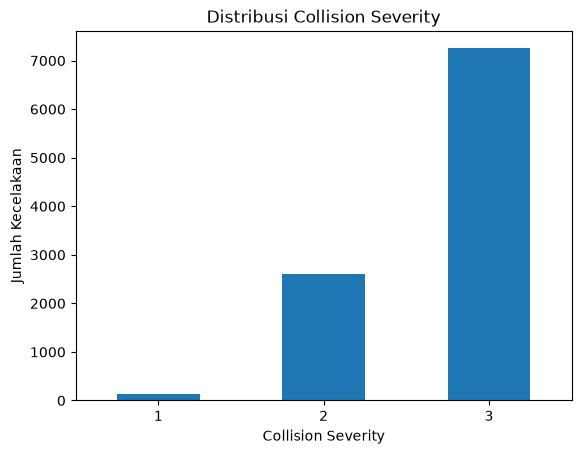

In [10]:
import matplotlib.pyplot as plt

severity_counts.plot(
    kind="bar",
    title="Distribusi Collision Severity"
)

plt.xlabel("Collision Severity")
plt.ylabel("Jumlah Kecelakaan")
plt.xticks(rotation=0)
plt.show()

In [11]:
code_columns = [
    "collision_severity",
    "day_of_week",
    "first_road_class",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "trunk_road_flag"
]

summary = []

for col in code_columns:
    summary.append({
        "column": col,
        "unique_count": df[col].nunique(dropna=False),
        "unique_values": sorted(df[col].dropna().unique().tolist())
    })

code_summary = pd.DataFrame(summary)

display(code_summary)

,column,unique_count,unique_values
0,collision_severity,3,"[1, 2, 3]"
1,day_of_week,7,"[1, 2, 3, 4, 5, 6, 7]"
2,first_road_class,6,"[1, 2, 3, 4, 5, 6]"
3,road_type,6,"[1, 2, 3, 6, 7, 9]"
4,speed_limit,6,"[20, 30, 40, 50, 60, 70]"
5,junction_detail,8,"[-1, 0, 13, 16, 17, 18, 19, 99]"
6,junction_control,6,"[-1, 1, 2, 3, 4, 9]"
7,light_conditions,5,"[1, 4, 5, 6, 7]"
8,weather_conditions,9,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
9,road_surface_conditions,7,"[-1, 1, 2, 3, 4, 5, 9]"


In [12]:
special_values = [-1, 9, 99]

for col in code_columns:
    found = {}

    for value in special_values:
        count = (df[col] == value).sum()
        if count > 0:
            found[value] = int(count)

    if found:
        print(f"{col}: {found}")

road_type: {9: 143}
junction_detail: {-1: 838, 99: 105}
junction_control: {-1: 4664, 9: 214}
weather_conditions: {9: 240}
road_surface_conditions: {-1: 95, 9: 100}
trunk_road_flag: {-1: 705}


In [13]:
df["collision_year"].value_counts().sort_index()

collision_year
2024    4126
2025    5874
Name: count, dtype: int64

In [14]:
pd.crosstab(
    df["collision_year"],
    df["collision_severity"]
)

collision_severity,1,2,3
collision_year,,,
2024,50,1105,2971
2025,87,1509,4278


In [15]:
df_full = pd.read_csv(DATA_PATH)

print(f"Jumlah baris: {len(df_full):,}")
print(f"Jumlah kolom: {df_full.shape[1]}")

C:\Users\Asyudi Anggara\AppData\Local\Temp\ipykernel_16956\2906801661.py:1: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(DATA_PATH)


Jumlah baris: 513,801
Jumlah kolom: 44


In [16]:
year_counts = (
    df_full["collision_year"]
    .value_counts()
    .sort_index()
)

display(year_counts)

collision_year
2021    101087
2022    106004
2023    104258
2024    100927
2025    101525
Name: count, dtype: int64

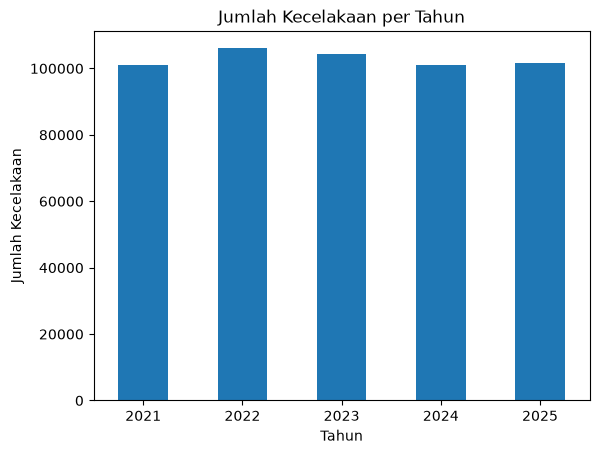

In [17]:
year_counts.plot(
    kind="bar",
    title="Jumlah Kecelakaan per Tahun"
)

plt.xlabel("Tahun")
plt.ylabel("Jumlah Kecelakaan")
plt.xticks(rotation=0)
plt.show()

In [18]:
sample_per_year = (
    df_full
    .groupby("collision_year", group_keys=False)
    .sample(
        n=2000,
        random_state=42
    )
)

print(sample_per_year.shape)

display(
    sample_per_year["collision_year"]
    .value_counts()
    .sort_index()
)

(10000, 44)


collision_year
2021    2000
2022    2000
2023    2000
2024    2000
2025    2000
Name: count, dtype: int64